In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [20]:
from Flamant.default import *
%cd -q {PROJECT_HOME}

import numpy as np
from Flamant.dataset import DummyTrussDataset
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from Flamant.losses import NodeEquilibriumLoss, StiffnessToLoadLoss, EnergyLoss
from Flamant.models.processing import StandardScaler
from Flamant.models.architecture import MLP
from torchmetrics import MeanAbsolutePercentageError

#device = torch.device(
#    'cuda' if torch.cuda.is_available()
#    else 'mps' if torch.backends.mps.is_available()
#    else 'cpu'                                         # mps only available for mac
#)

from matplotlib import pyplot as plt

filname = r"C:\Users\louis\PycharmProjects\Master_Thesis\Flamant\data\dataset\dummy_truss"
ds_train = DummyTrussDataset(f"{filname}/val_8192.hdf5") # Flamant's was 4096
ds_val = DummyTrussDataset(f"{filname}/val_512.hdf5")

dl_train = DataLoader(ds_train, batch_size=512)
dl_val = DataLoader(ds_val, batch_size=512)

#device = 'mps'

mape = MeanAbsolutePercentageError().to(device)
N_EPOCH = 1600
LR = 1e-3



Creates the MLP model with number of inputs, dimension of hidden layers (3 layers of 50?), number of outputs, activation function
Cell also has the full training loop of the data to fit the parameters of the model

In [21]:
model = MLP(11, [50]*3, 5, activation='tanh', activation_params=None).to(device)
#def model = MLP(11, [50]*3, 5, activation='tanh', activation_params=None).to(device)

optimizer = Adam(lr=LR, params=model.parameters())
loss_fn = nn.MSELoss().to(device)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=50, factor=.5)

x_scaler = StandardScaler(11).to(device)
y_scaler = StandardScaler(5).to(device)
for x, y, _, _, _, _ in dl_train:
    x_scaler.partial_fit(x.to(device))
    y_scaler.partial_fit(y.to(device))

losses = []
val_losses = []
for epoch in range(N_EPOCH):
    loss_step = []
    for x, y, _, _, _, _ in dl_train:
        x = x.to(device)
        y = y.to(device)

        z_x = x_scaler.transform(x)
        z_y = y_scaler.transform(y)

        z_y_pred = model(z_x)
        y_pred = y_scaler.inverse_transform(z_y_pred)

        optimizer.zero_grad()
        loss = loss_fn(z_y_pred, z_y)
        loss.backward()
        loss_step.append(loss.item())
        optimizer.step()
    losses.append(np.mean(loss_step))

    for x, y, _, _, _, _ in dl_val:
        with torch.no_grad():
            x = x.to(device)
            y = y.to(device)

            z_x = x_scaler.transform(x)
            z_y = y_scaler.transform(y)

            z_y_pred = model(z_x)
            y_pred = y_scaler.inverse_transform(z_y_pred)

            loss = loss_fn(z_y_pred, z_y)
            val_losses.append(loss.item())

    scheduler.step(torch.tensor(val_losses).mean())

This cell evaluates model/visualizes it.

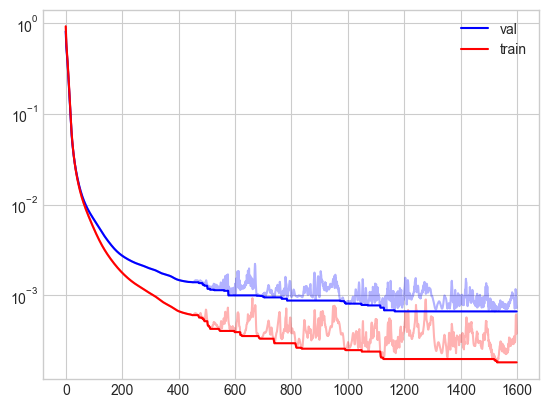

MAPE: 0.017


In [22]:
plt.plot(val_losses, color='b', alpha=.3)
plt.plot(losses, color='r', alpha=.3)
plt.plot(np.minimum.accumulate(val_losses), color='b', label='val')
plt.plot(np.minimum.accumulate(losses), color='r', label='train')
plt.yscale('log')
plt.legend()
plt.show()

for x, y, _, _, _, _ in dl_val:
    with torch.no_grad():
        x = x.to(device)
        y = y.to(device)

        z_x = x_scaler.transform(x)
        z_y = y_scaler.transform(y)

        z_y_pred = model(z_x)
        y_pred = y_scaler.inverse_transform(z_y_pred)

        print(f"MAPE: {mape(y_pred, y):.3f}")

Similar to cell 2 but evaluates with respect to noise sensitivity and compares to analytical benchmark.

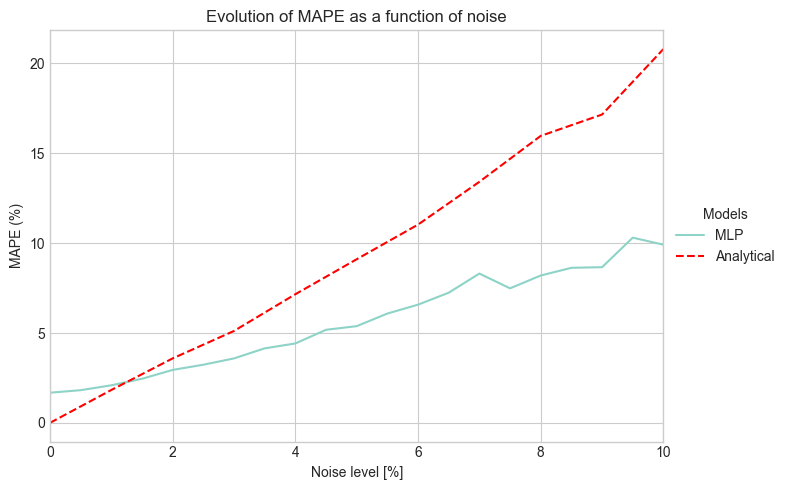

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define the noise levels
noise_levels = np.linspace(0, 0.1, 21)

mapes = []
for noise in noise_levels:
    ds = DummyTrussDataset('data/dataset/dummy_truss/val_512.hdf5',
                           f_noise_loads=lambda size: np.random.normal(1, noise / 2, size),
                           f_noise_displacement=lambda size: np.random.normal(1, noise / 2, size),
                           f_noise_strain=lambda size: np.random.normal(1, noise / 2, size)
                           )
    dl = DataLoader(ds, batch_size=512)

    mapes_epoch = []
    for x, y, _, _, _, _ in dl:
        with torch.no_grad():
            x = x.to(device)
            y = y.to(device)

            z_x = x_scaler.transform(x)
            z_y = y_scaler.transform(y)

            z_y_pred = model(z_x)
            y_pred = y_scaler.inverse_transform(z_y_pred)

            mapes_epoch.append(mape(y_pred, y))
    mapes.append(torch.tensor(mapes_epoch).mean())

mapes = torch.tensor(mapes)

fig, ax = plt.subplots(figsize=(8, 5))  # Wider figure for space

# MAPE Plot
ax.plot(noise_levels * 100,  mapes* 100, label='MLP')

# Analytical benchmark
analy_data = np.loadtxt(r"/Dummy_Truss\analytical_noise_sensitivity.txt", delimiter=",")
x = analy_data[0:11, 0]   # noise levels
y = analy_data[:, 1]   # mape values
analytical_results = y[0:11]
#analytical_results = np.loadtxt(r'experiments/dummy_truss/analytical_mean_mape.dat')
ax.plot(x, analytical_results, c='red', linestyle='--', label="Analytical")
ax.set_xlim(0,10)
#analytical_results = np.loadtxt(r'experiments/dummy_truss/analytical_mean_mape.dat')
#ax.plot(noise_levels * 100, analytical_results * 100, linestyle='--', label="Analytical")

# Labels and formatting
ax.set_ylabel("MAPE (%)")
ax.set_title("Evolution of MAPE as a function of noise")
ax.set_xlabel("Noise level [%]")
ax.grid(True)

# Move legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Models")

plt.tight_layout()  # Make room for legend

# Save
#fig.savefig(r"experiments/dummy_truss/03_truss_example_classical_model_noise_mape.pdf")

plt.show()


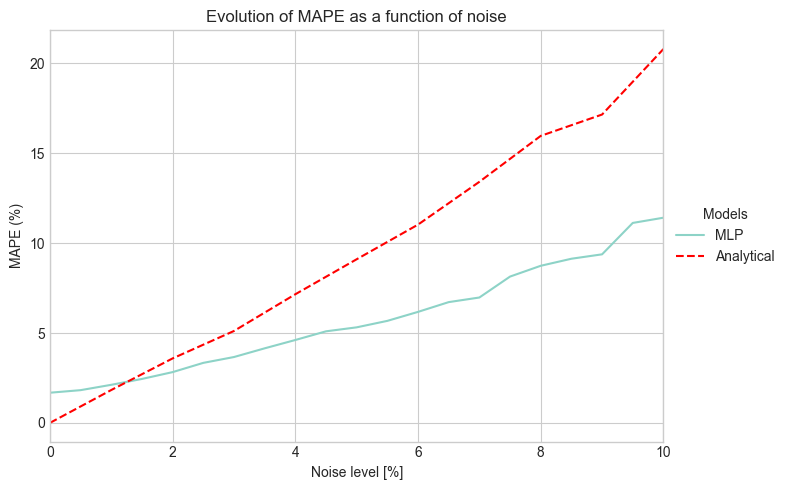

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define the noise levels
noise_levels = np.linspace(0, 0.1, 21)

mapes = []
for noise in noise_levels:
    ds = DummyTrussDataset('data/dataset/dummy_truss/val_512.hdf5',
                           f_noise_loads=lambda size: np.random.normal(1, noise / 2, size),
                           f_noise_displacement=lambda size: np.random.normal(1, noise / 2, size),
                           f_noise_strain=lambda size: np.random.normal(1, noise / 2, size)
                           )
    dl = DataLoader(ds, batch_size=512)

    mapes_epoch = []
    for x, y, _, _, _, _ in dl:
        with torch.no_grad():
            x = x.to(device)
            y = y.to(device)

            z_x = x_scaler.transform(x)
            z_y = y_scaler.transform(y)

            z_y_pred = model(z_x)
            y_pred = y_scaler.inverse_transform(z_y_pred)

            mapes_epoch.append(mape(y_pred, y))
    mapes.append(torch.tensor(mapes_epoch).mean())

mapes = torch.tensor(mapes)

plt.style.use("seaborn-v0_8-whitegrid")  # clean academic style
fig, ax = plt.subplots(figsize=(8, 5))  # Wider figure for space

# MAPE Plot
ax.plot(noise_levels * 100,  mapes* 100, label='MLP')

# Analytical benchmark
analy_data = np.loadtxt(r"/Dummy_Truss\analytical_noise_sensitivity.txt", delimiter=",")
x = analy_data[0:11, 0]   # noise levels
y = analy_data[:, 1]   # mape values
analytical_results = y[0:11]
ax.plot(x, analytical_results, c='red', linestyle='--', label="Analytical")
ax.set_xlim(0,10)
#analytical_results = np.loadtxt(r'experiments/dummy_truss/analytical_mean_mape.dat')
#ax.plot(noise_levels * 100, analytical_results * 100, linestyle='--', label="Analytical")

# Labels and formatting
ax.set_ylabel("MAPE (%)")
ax.set_title("Evolution of MAPE as a function of noise")
ax.set_xlabel("Noise level [%]")
ax.grid(True)

# Move legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Models")

plt.tight_layout()  # Make room for legend

# Save
#fig.savefig(r"experiments/dummy_truss/03_truss_example_classical_model_noise_mape.pdf")
fig.savefig("MLP_vs_analy_noise.pdf", bbox_inches='tight', transparent=False)


plt.show()